In [2]:
from pathlib import Path
import os

# Current working directory
print("CWD:", os.getcwd())

# Project root = current folder (should be ...\clinsightai)
ROOT = Path.cwd()

# If your CWD accidentally becomes ...\notebooks, this will fix it:
if (ROOT / "data_raw").exists() is False and (ROOT.parent / "data_raw").exists():
    ROOT = ROOT.parent

CSV_PATH = ROOT / "data_raw" / "hospital.csv"

print("Resolved ROOT:", ROOT)
print("CSV_PATH:", CSV_PATH)
print("File exists?", CSV_PATH.exists())

CWD: c:\Users\Admin\Downloads\clinsightai
Resolved ROOT: c:\Users\Admin\Downloads\clinsightai
CSV_PATH: c:\Users\Admin\Downloads\clinsightai\data_raw\hospital.csv
File exists? True


In [3]:
import pandas as pd

df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (996, 4)
Columns: ['Feedback', 'Sentiment Label', 'Ratings', 'Unnamed: 3']


,Feedback,Sentiment Label,Ratings,Unnamed: 3
0,Good and clean hospital. There is great team o...,1,5,NaN
1,Had a really bad experience during discharge. ...,1,5,NaN
2,I have visited to take my second dose and Proc...,1,4,NaN
3,That person was slightly clueless and offered...,1,3,NaN
4,There is great team of doctors and good OT fac...,0,1,NaN


In [4]:
print(df.dtypes)

missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("\nMissing % by column:\n", missing_pct)

Feedback            object
Sentiment Label      int64
Ratings              int64
Unnamed: 3         float64
dtype: object

Missing % by column:
 Unnamed: 3         100.0
Feedback             0.0
Sentiment Label      0.0
Ratings              0.0
dtype: float64


In [5]:
import re
import pandas as pd

df2 = df.copy()

# Drop useless column
if "Unnamed: 3" in df2.columns:
    df2 = df2.drop(columns=["Unnamed: 3"])

# Rename to our standard schema
df2 = df2.rename(columns={
    "Feedback": "review_text",
    "Ratings": "rating",
    "Sentiment Label": "sentiment_label"
})

# Basic text cleanup
def clean_text(s: str) -> str:
    s = str(s)
    s = s.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s

df2["review_text"] = df2["review_text"].apply(clean_text)

# Keep valid ratings only (1–5)
df2 = df2[df2["rating"].between(1, 5)].copy()

print("Clean shape:", df2.shape)
df2.head()

Clean shape: (996, 3)


,review_text,sentiment_label,rating
0,Good and clean hospital. There is great team o...,1,5
1,Had a really bad experience during discharge. ...,1,5
2,I have visited to take my second dose and Proc...,1,4
3,That person was slightly clueless and offered ...,1,3
4,There is great team of doctors and good OT fac...,0,1


In [6]:
print("Rating distribution:\n", df2["rating"].value_counts().sort_index())
print("\nEmpty review_text rows:", (df2["review_text"].str.len() == 0).sum())

# Just to ensure no weird nulls
print("\nNulls:\n", df2.isna().sum())

Rating distribution:
 rating
1    123
2    145
3    123
4    254
5    351
Name: count, dtype: int64

Empty review_text rows: 0

Nulls:
 review_text        0
sentiment_label    0
rating             0
dtype: int64


In [7]:
from pathlib import Path

OUT_PATH = ROOT / "data_clean" / "reviews_clean.csv"
df2.to_csv(OUT_PATH, index=False)
print("Saved:", OUT_PATH)

Saved: c:\Users\Admin\Downloads\clinsightai\data_clean\reviews_clean.csv


In [9]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Load clean data
df = pd.read_csv(ROOT / "data_clean" / "reviews_clean.csv")

print("Total reviews:", len(df))

# Load embedding model (lightweight but powerful)
model = SentenceTransformer("all-MiniLM-L6-v2")

# Create embeddings
embeddings = model.encode(
    df["review_text"].tolist(),
    show_progress_bar=True
)

print("Embedding shape:", np.array(embeddings).shape)

Total reviews: 996


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Embedding shape: (996, 384)


In [10]:
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Ensure embeddings is a numpy array
X = np.array(embeddings)

# Try a range of K values (themes)
k_values = list(range(6, 21))  # 6 to 20 themes
results = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    results.append((k, score))

res_df = pd.DataFrame(results, columns=["k", "silhouette"]).sort_values("silhouette", ascending=False)
print(res_df.head(10))

best_k = int(res_df.iloc[0]["k"])
print("\nBest K by silhouette:", best_k)

# Fit final model with best_k
km_final = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
df["cluster_id"] = km_final.fit_predict(X)

print("\nCluster sizes:")
print(df["cluster_id"].value_counts().sort_index())

     k  silhouette
1    7    0.030213
13  19    0.029199
0    6    0.028216
8   14    0.028171
9   15    0.027942
14  20    0.027879
10  16    0.027770
7   13    0.027229
11  17    0.026958
12  18    0.026661

Best K by silhouette: 7

Cluster sizes:
cluster_id
0     91
1    315
2    174
3    148
4    231
5     20
6     17
Name: count, dtype: int64


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Fit TFIDF on full dataset
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=3000,
    ngram_range=(1,2)
)

tfidf_matrix = vectorizer.fit_transform(df["review_text"])
feature_names = np.array(vectorizer.get_feature_names_out())

theme_summaries = []

for cluster_id in sorted(df["cluster_id"].unique()):
    
    cluster_mask = df["cluster_id"] == cluster_id
    cluster_indices = np.where(cluster_mask)[0]
    
    # Mean TFIDF scores inside cluster
    cluster_tfidf_mean = tfidf_matrix[cluster_indices].mean(axis=0)
    cluster_tfidf_mean = np.asarray(cluster_tfidf_mean).flatten()
    
    top_indices = cluster_tfidf_mean.argsort()[-10:][::-1]
    top_keywords = feature_names[top_indices]
    
    avg_rating = df.loc[cluster_mask, "rating"].mean()
    frequency_pct = round(len(cluster_indices) / len(df) * 100, 2)
    
    example_reviews = df.loc[cluster_mask, "review_text"].head(3).tolist()
    
    theme_summaries.append({
        "cluster_id": cluster_id,
        "frequency_%": frequency_pct,
        "avg_rating": round(avg_rating, 2),
        "top_keywords": list(top_keywords),
        "examples": example_reviews
    })

for theme in theme_summaries:
    print("\n=============================")
    print("Cluster:", theme["cluster_id"])
    print("Frequency %:", theme["frequency_%"])
    print("Avg Rating:", theme["avg_rating"])
    print("Top Keywords:", theme["top_keywords"])
    print("Example Review:", theme["examples"][0])


Cluster: 0
Frequency %: 9.14
Avg Rating: 2.32
Top Keywords: ['doctors', 'patient', 'worst', 'staff', 'doctor', 'hospital', 'good', 'patients', 'rude', 'lab']
Example Review: Recently underwent a surgery for my left shoulder, the doctors are extremely good, but the management needs to be more patient oriented than money minded.

Cluster: 1
Frequency %: 31.63
Avg Rating: 4.47
Top Keywords: ['dr', 'good', 'treatment', 'doctor', 'care', 'doctors', 'excellent', 'experience', 'hospital', 'staff']
Example Review: I have visited to take my second dose and Process was really smooth. Hospitality from all staffs are really appreciable. Shanti tooks good care and provide all details before vaccination. Thank you.

Cluster: 2
Frequency %: 17.47
Avg Rating: 2.45
Top Keywords: ['doctor', 'wait', 'appointment', 'time', 'test', 'hospital', 'patient', 'patients', 'emergency', 'waiting']
Example Review: Had a really bad experience during discharge. They need to be sensitive and more transparent towards 

In [12]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

# One-hot encode clusters
cluster_dummies = pd.get_dummies(df["cluster_id"], prefix="cluster")

X = cluster_dummies
y = df["rating"]

# Fit regression model
model = LinearRegression()
model.fit(X, y)

# Get coefficients
coefficients = pd.Series(model.coef_, index=X.columns)

impact_df = pd.DataFrame({
    "cluster": coefficients.index,
    "rating_impact": coefficients.values
})

impact_df = impact_df.sort_values("rating_impact")

print("\nCluster Impact on Rating:")
print(impact_df)

print("\nModel R^2 Score:", model.score(X, y))


Cluster Impact on Rating:
     cluster  rating_impact
0  cluster_0      -1.230432
2  cluster_2      -1.100837
3  cluster_3      -0.177491
4  cluster_4       0.139199
5  cluster_5       0.350887
1  cluster_1       0.920728
6  cluster_6       1.097946

Model R^2 Score: 0.32789944518153447


In [13]:
# Merge frequency data
cluster_freq = df["cluster_id"].value_counts(normalize=True)

severity_data = []

for cluster_id in sorted(df["cluster_id"].unique()):
    impact = impact_df.loc[impact_df["cluster"] == f"cluster_{cluster_id}", "rating_impact"].values[0]
    frequency = cluster_freq[cluster_id]
    
    severity_score = abs(impact) * frequency
    
    severity_data.append({
        "cluster_id": cluster_id,
        "frequency_%": round(frequency * 100, 2),
        "rating_impact": round(impact, 3),
        "severity_score": round(severity_score, 3)
    })

severity_df = pd.DataFrame(severity_data).sort_values("severity_score", ascending=False)

print(severity_df)

   cluster_id  frequency_%  rating_impact  severity_score
1           1        31.63          0.921           0.291
2           2        17.47         -1.101           0.192
0           0         9.14         -1.230           0.112
4           4        23.19          0.139           0.032
3           3        14.86         -0.177           0.026
6           6         1.71          1.098           0.019
5           5         2.01          0.351           0.007


In [14]:
import numpy as np
import pandas as pd

# --- Representative samples per cluster using distance to centroid ---
centroids = km_final.cluster_centers_
labels = df["cluster_id"].values

rep_rows = []
for c in sorted(df["cluster_id"].unique()):
    idx = np.where(labels == c)[0]
    # distance from each point in cluster to its centroid
    dists = np.linalg.norm(X[idx] - centroids[c], axis=1)
    top_local = np.argsort(dists)[:5]  # 5 most representative
    top_idx = idx[top_local]
    
    for rank, i in enumerate(top_idx, start=1):
        rep_rows.append({
            "cluster_id": c,
            "rank": rank,
            "rating": int(df.iloc[i]["rating"]),
            "review_text": df.iloc[i]["review_text"]
        })

rep_df = pd.DataFrame(rep_rows).sort_values(["cluster_id", "rank"])
rep_df

KeyError: "None of [Index([  7,  59,  81, 109, 119, 132, 143, 148, 149, 221, 240, 277, 280, 281,\n       282, 287, 288, 294, 304, 311, 345, 347, 357, 358, 373, 385, 387, 400,\n       401, 402, 436, 446, 472, 493, 495, 503, 522, 529, 535, 543, 564, 581,\n       590, 594, 595, 600, 618, 628, 632, 638, 664, 666, 669, 676, 677, 687,\n       696, 702, 729, 731, 753, 760, 764, 775, 786, 795, 803, 806, 812, 818,\n       826, 832, 838, 840, 846, 853, 868, 879, 904, 908, 913, 938, 940, 943,\n       945, 963, 965, 969, 972, 980, 993],\n      dtype='int64')] are in the [columns]"

In [15]:
import numpy as np
import pandas as pd

# 1) Make sure df index is 0..n-1
df = df.reset_index(drop=True)

# 2) Force embeddings -> numpy array (not DataFrame)
X = np.asarray(embeddings, dtype=np.float32)

print("df shape:", df.shape)
print("X shape:", X.shape)
print("X type:", type(X))

df shape: (996, 4)
X shape: (996, 384)
X type: <class 'numpy.ndarray'>


In [16]:
# --- Representative samples per cluster using distance to centroid ---
centroids = km_final.cluster_centers_
labels = df["cluster_id"].to_numpy()

rep_rows = []
for c in sorted(df["cluster_id"].unique()):
    idx = np.where(labels == c)[0]

    # distance from each point in cluster to its centroid
    dists = np.linalg.norm(X[idx] - centroids[c], axis=1)

    top_local = np.argsort(dists)[:5]  # 5 most representative
    top_idx = idx[top_local]

    for rank, i in enumerate(top_idx, start=1):
        rep_rows.append({
            "cluster_id": int(c),
            "rank": int(rank),
            "rating": int(df.loc[i, "rating"]),
            "review_text": df.loc[i, "review_text"]
        })

rep_df = pd.DataFrame(rep_rows).sort_values(["cluster_id", "rank"])
rep_df

,cluster_id,rank,rating,review_text
0,0,1,4,Staff is so polite and friendly Doctors are ki...
1,0,2,1,Hospital doctors are not good
2,0,3,2,Hospital doctors are not good.
3,0,4,3,Doctor consultation is excellent but the servi...
4,0,5,3,Doctors are good but the mangement and service...
5,1,1,5,I had an good experience in this Hospital wher...
6,1,2,4,I had an good experience in this Hospital wher...
7,1,3,4,Good service and excellent treatments from doc...
8,1,4,5,Had a very good experience with the hospital d...
9,1,5,5,All services are good. Doctors and nurses are ...


In [17]:
# Create theme name mapping
theme_names = {
    0: "Clinical Quality vs Management Gap",
    1: "High Satisfaction – Overall Care",
    2: "Wait Time & Poor Coordination",
    3: "Staff Courtesy & Service Quality",
    4: "General Facilities & Infrastructure",
    5: "Premium Service Experience",
    6: "Individual Staff Appreciation"
}

severity_df["theme_name"] = severity_df["cluster_id"].map(theme_names)

# Merge with average rating per cluster
avg_rating = df.groupby("cluster_id")["rating"].mean().round(2)
severity_df["avg_rating"] = severity_df["cluster_id"].map(avg_rating)

severity_df = severity_df.sort_values("severity_score", ascending=False)

severity_df

,cluster_id,frequency_%,rating_impact,severity_score,theme_name,avg_rating
1,1,31.63,0.921,0.291,High Satisfaction – Overall Care,4.47
2,2,17.47,-1.101,0.192,Wait Time & Poor Coordination,2.45
0,0,9.14,-1.230,0.112,Clinical Quality vs Management Gap,2.32
4,4,23.19,0.139,0.032,General Facilities & Infrastructure,3.69
3,3,14.86,-0.177,0.026,Staff Courtesy & Service Quality,3.37
6,6,1.71,1.098,0.019,Individual Staff Appreciation,4.65
5,5,2.01,0.351,0.007,Premium Service Experience,3.90


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Define binary risk target
df["rating_class"] = np.where(df["rating"] <= 2, 0, 1)

# Use cluster dummies as features
X = pd.get_dummies(df["cluster_id"], prefix="cluster")
y = df["rating_class"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

# Evaluate
preds = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print("\nClassification Report:\n")
print(classification_report(y_test, preds))

# Feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns)
importance_df = importances.sort_values(ascending=False).reset_index()
importance_df.columns = ["cluster", "importance"]

importance_df

Accuracy: 0.835

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.59      0.66        54
           1       0.86      0.92      0.89       146

    accuracy                           0.83       200
   macro avg       0.80      0.76      0.78       200
weighted avg       0.83      0.83      0.83       200



,cluster,importance
0,cluster_2,0.343483
1,cluster_1,0.313672
2,cluster_0,0.181655
3,cluster_4,0.071968
4,cluster_3,0.051498
5,cluster_6,0.025561
6,cluster_5,0.012163


In [19]:
# Map importance to cluster_id
importance_df["cluster_id"] = importance_df["cluster"].str.replace("cluster_", "").astype(int)

# Merge with severity + theme table
risk_df = severity_df.merge(
    importance_df[["cluster_id", "importance"]],
    on="cluster_id",
    how="left"
)

# Create composite business risk score
# Combining: frequency, rating impact magnitude, and ML importance

risk_df["risk_score"] = (
    abs(risk_df["rating_impact"]) * 0.4 +
    risk_df["importance"] * 0.4 +
    (risk_df["frequency_%"] / 100) * 0.2
)

risk_df = risk_df.sort_values("risk_score", ascending=False)

risk_df

,cluster_id,frequency_%,rating_impact,severity_score,theme_name,avg_rating,importance,risk_score
1,2,17.47,-1.101,0.192,Wait Time & Poor Coordination,2.45,0.343483,0.612733
2,0,9.14,-1.230,0.112,Clinical Quality vs Management Gap,2.32,0.181655,0.582942
0,1,31.63,0.921,0.291,High Satisfaction – Overall Care,4.47,0.313672,0.557129
5,6,1.71,1.098,0.019,Individual Staff Appreciation,4.65,0.025561,0.452844
6,5,2.01,0.351,0.007,Premium Service Experience,3.90,0.012163,0.149285
3,4,23.19,0.139,0.032,General Facilities & Infrastructure,3.69,0.071968,0.130767
4,3,14.86,-0.177,0.026,Staff Courtesy & Service Quality,3.37,0.051498,0.121119


In [20]:
roadmap = []

for _, row in risk_df.iterrows():
    
    if row["rating_impact"] < 0:
        priority = "High"
        action_type = "Risk Mitigation"
    else:
        priority = "Strategic Reinforcement"
        action_type = "Retention Driver"
    
    expected_lift = round(abs(row["rating_impact"]) * 0.5, 2)
    
    roadmap.append({
        "theme": row["theme_name"],
        "priority": priority,
        "action_type": action_type,
        "recommended_action": f"Operational audit and KPI tracking for {row['theme_name']}",
        "expected_rating_lift": f"+{expected_lift}",
        "confidence_score": round(row["importance"], 2)
    })

roadmap_df = pd.DataFrame(roadmap)

roadmap_df

,theme,priority,action_type,recommended_action,expected_rating_lift,confidence_score
0,Wait Time & Poor Coordination,High,Risk Mitigation,Operational audit and KPI tracking for Wait Ti...,+0.55,0.34
1,Clinical Quality vs Management Gap,High,Risk Mitigation,Operational audit and KPI tracking for Clinica...,+0.61,0.18
2,High Satisfaction – Overall Care,Strategic Reinforcement,Retention Driver,Operational audit and KPI tracking for High Sa...,+0.46,0.31
3,Individual Staff Appreciation,Strategic Reinforcement,Retention Driver,Operational audit and KPI tracking for Individ...,+0.55,0.03
4,Premium Service Experience,Strategic Reinforcement,Retention Driver,Operational audit and KPI tracking for Premium...,+0.18,0.01
5,General Facilities & Infrastructure,Strategic Reinforcement,Retention Driver,Operational audit and KPI tracking for General...,+0.07,0.07
6,Staff Courtesy & Service Quality,High,Risk Mitigation,Operational audit and KPI tracking for Staff C...,+0.09,0.05


In [21]:
import json

final_output = {
    "clinic_summary": {
        "overall_rating_mean": round(df["rating"].mean(), 2),
        "primary_risk_themes": list(
            risk_df[risk_df["rating_impact"] < 0]
            .sort_values("risk_score", ascending=False)
            .head(2)["theme_name"]
        ),
        "primary_growth_drivers": list(
            risk_df[risk_df["rating_impact"] > 0]
            .sort_values("risk_score", ascending=False)
            .head(2)["theme_name"]
        )
    },
    "theme_analysis": [],
    "improvement_roadmap": []
}

# Add theme analysis
for _, row in risk_df.iterrows():
    final_output["theme_analysis"].append({
        "theme": row["theme_name"],
        "frequency_percentage": row["frequency_%"],
        "average_rating": row["avg_rating"],
        "rating_impact": row["rating_impact"],
        "ml_importance": round(row["importance"], 3),
        "risk_score": round(row["risk_score"], 3),
        "confidence_score": round(row["importance"], 2)
    })

# Add roadmap
for _, row in roadmap_df.iterrows():
    final_output["improvement_roadmap"].append({
        "theme": row["theme"],
        "priority": row["priority"],
        "action_type": row["action_type"],
        "expected_rating_lift": row["expected_rating_lift"],
        "confidence_score": row["confidence_score"]
    })

print(json.dumps(final_output, indent=2))

{
  "clinic_summary": {
    "overall_rating_mean": 3.57,
    "primary_risk_themes": [
      "Wait Time & Poor Coordination",
      "Clinical Quality vs Management Gap"
    ],
    "primary_growth_drivers": [
      "High Satisfaction \u2013 Overall Care",
      "Individual Staff Appreciation"
    ]
  },
  "theme_analysis": [
    {
      "theme": "Wait Time & Poor Coordination",
      "frequency_percentage": 17.47,
      "average_rating": 2.45,
      "rating_impact": -1.101,
      "ml_importance": 0.343,
      "risk_score": 0.613,
      "confidence_score": 0.34
    },
    {
      "theme": "Clinical Quality vs Management Gap",
      "frequency_percentage": 9.14,
      "average_rating": 2.32,
      "rating_impact": -1.23,
      "ml_importance": 0.182,
      "risk_score": 0.583,
      "confidence_score": 0.18
    },
    {
      "theme": "High Satisfaction \u2013 Overall Care",
      "frequency_percentage": 31.63,
      "average_rating": 4.47,
      "rating_impact": 0.921,
      "ml_importanc

In [22]:
import json
import pandas as pd

# 1) Take top evidence samples per cluster from your rep_df (most representative)
evidence_map = (
    rep_df.sort_values(["cluster_id", "rank"])
         .groupby("cluster_id")["review_text"]
         .apply(lambda s: s.head(3).tolist())
         .to_dict()
)

# 2) Helper: KPI suggestions per theme (simple but strong for demo)
kpi_map = {
    "Wait Time & Poor Coordination": ["Avg wait time (mins)", "On-time appointment %", "Queue abandonment rate", "Complaints per 100 visits"],
    "Clinical Quality vs Management Gap": ["Post-visit issue rate", "Billing dispute rate", "Discharge turnaround time", "Follow-up completion %"],
    "Staff Courtesy & Service Quality": ["Courtesy score (survey)", "Complaint resolution SLA", "Staff responsiveness score"],
    "General Facilities & Infrastructure": ["Cleanliness score", "Facility issue tickets per week", "Downtime incidents"],
    "High Satisfaction – Overall Care": ["NPS/CSAT", "Repeat visit rate", "Review volume growth"],
    "Premium Service Experience": ["5-star share %", "Service recovery success %"],
    "Individual Staff Appreciation": ["Staff mentions per 100 reviews", "Recognition conversion rate"]
}

# 3) Upgrade the JSON to include evidence + actions + KPIs + effort bucket
final_output_v2 = final_output.copy()
final_output_v2["theme_analysis"] = []
final_output_v2["improvement_roadmap"] = []

# Add theme analysis with evidence and explainability
for _, row in risk_df.iterrows():
    theme = row["theme_name"]
    cid = int(row["cluster_id"])
    final_output_v2["theme_analysis"].append({
        "theme": theme,
        "cluster_id": cid,
        "frequency_percentage": float(row["frequency_%"]),
        "average_rating": float(row["avg_rating"]),
        "rating_impact": float(row["rating_impact"]),
        "ml_importance": float(round(row["importance"], 3)),
        "risk_score": float(round(row["risk_score"], 3)),
        "confidence_score": float(round(row["importance"], 2)),
        "why_identified": "Theme derived from embedding-based clustering; validated via top TF-IDF keywords and representative reviews near the cluster centroid.",
        "evidence_samples": evidence_map.get(cid, [])[:3],
        "suggested_kpis": kpi_map.get(theme, [])
    })

# Roadmap: make it business-like with effort buckets + quick wins
def effort_bucket(theme):
    if theme in ["Wait Time & Poor Coordination", "Clinical Quality vs Management Gap"]:
        return "High-effort improvement"
    if theme in ["Staff Courtesy & Service Quality", "General Facilities & Infrastructure"]:
        return "Quick win"
    return "Reinforce & monitor"

def recommendation(theme):
    recs = {
        "Wait Time & Poor Coordination": "Optimize appointment scheduling + triage; add live queue visibility; enforce on-time SLA.",
        "Clinical Quality vs Management Gap": "Standardize discharge/billing communication; train front-desk workflow; implement escalation path.",
        "Staff Courtesy & Service Quality": "Run service training; implement complaint-resolution SLA and coaching loop.",
        "General Facilities & Infrastructure": "Facility checklist + ticketing; weekly audits on cleanliness and amenities.",
        "High Satisfaction – Overall Care": "Protect top-performing workflows; replicate best practices across shifts/units.",
        "Premium Service Experience": "Document what drives 5-star visits and scale those service patterns.",
        "Individual Staff Appreciation": "Launch staff recognition program; use mentions as coaching and reward signals."
    }
    return recs.get(theme, f"Operational audit and KPI tracking for {theme}")

# Build roadmap (prioritize negative first)
roadmap_sorted = risk_df.sort_values(["rating_impact", "risk_score"], ascending=[True, False])

priority_rank = 1
for _, row in roadmap_sorted.iterrows():
    theme = row["theme_name"]
    lift = round(abs(row["rating_impact"]) * 0.5, 2)
    final_output_v2["improvement_roadmap"].append({
        "priority": priority_rank,
        "theme": theme,
        "recommendation": recommendation(theme),
        "effort_bucket": effort_bucket(theme),
        "expected_rating_lift": f"+{lift}",
        "confidence": float(round(row["importance"], 2)),
        "kpis_to_track": kpi_map.get(theme, [])
    })
    priority_rank += 1

# 4) Save to file so nothing truncates
out_path = ROOT / "outputs" / "clinsightai_report.json"
out_path.parent.mkdir(parents=True, exist_ok=True)

with open(out_path, "w", encoding="utf-8") as f:
    json.dump(final_output_v2, f, indent=2, ensure_ascii=False)

print("Saved full report to:", out_path)
print("Theme count:", len(final_output_v2["theme_analysis"]))
print("Roadmap items:", len(final_output_v2["improvement_roadmap"]))

Saved full report to: c:\Users\Admin\Downloads\clinsightai\outputs\clinsightai_report.json
Theme count: 7
Roadmap items: 7


In [23]:
import json
from pathlib import Path

report_path = ROOT / "outputs" / "clinsightai_report.json"
report = json.loads(Path(report_path).read_text(encoding="utf-8"))

overall = report["clinic_summary"]["overall_rating_mean"]
risks = report["clinic_summary"]["primary_risk_themes"]
drivers = report["clinic_summary"]["primary_growth_drivers"]

# Pull top 2 risks (already ordered) and some numbers
theme_lookup = {t["theme"]: t for t in report["theme_analysis"]}

r1, r2 = risks[0], risks[1]
d1, d2 = drivers[0], drivers[1]

def fmt_theme(theme):
    t = theme_lookup[theme]
    return (f"{theme} (freq {t['frequency_percentage']}%, impact {t['rating_impact']}, "
            f"avg rating {t['average_rating']}, confidence {t['confidence_score']})")

exec_summary = f"""
EXECUTIVE SUMMARY (for clinic owners)

Overall rating average: {overall}

Top operational risks driving low ratings:
1) {fmt_theme(r1)}
2) {fmt_theme(r2)}

Top strengths to protect and scale:
1) {fmt_theme(d1)}
2) {fmt_theme(d2)}

What this means:
- Fixing {r1} is the fastest path to reduce 1–2 star reviews because it is both frequent and strongly predictive of low ratings.
- {r2} has the largest rating drop per occurrence, so it needs escalation workflows and standardization.

Recommended next actions (30–45 days):
- Quick wins: improve visibility + communication (queue transparency, proactive updates), service recovery SOPs, complaint SLA.
- High-effort: scheduling redesign, triage optimization, front-desk + discharge/billing standardization.
""".strip()

# Build demo script from roadmap
roadmap = report["improvement_roadmap"]
top3 = roadmap[:3]

demo_script = f"""
5–7 MIN DEMO SCRIPT (stakeholder-friendly)

Slide 1 — Problem:
Healthcare reviews are unstructured. Owners can’t quantify what operational issues truly drive ratings or what to fix first.

Slide 2 — What ClinsightAI does:
We convert reviews into structured operational themes, quantify rating impact, detect systemic issues, and output a prioritized improvement roadmap with KPIs.

Slide 3 — Data:
Kaggle hospital reviews (996 reviews), rating 1–5. No PHI.

Slide 4 — Theme Discovery:
We embed each review (SentenceTransformer all-MiniLM-L6-v2) and cluster them into themes (KMeans best K=7).
We label each theme using TF-IDF keywords + representative reviews.

Slide 5 — Impact Quantification:
We estimate rating impact using:
- Regression coefficients (effect size)
- Classification model predicting low vs high rating (RandomForest, accuracy ~0.83)
This produces risk scores (frequency + impact + ML importance).

Slide 6 — Key Findings:
Overall rating mean: {overall}
Top risks:
- {fmt_theme(r1)}
- {fmt_theme(r2)}
Top strengths:
- {fmt_theme(d1)}

Slide 7 — Business Roadmap (prioritized):
Priority 1: {top3[0]['theme']} → {top3[0]['recommendation']} | KPIs: {", ".join(top3[0]['kpis_to_track'][:3])}
Priority 2: {top3[1]['theme']} → {top3[1]['recommendation']} | KPIs: {", ".join(top3[1]['kpis_to_track'][:3])}
Priority 3: {top3[2]['theme']} → {top3[2]['recommendation']} | KPIs: {", ".join(top3[2]['kpis_to_track'][:3])}

Close:
ClinsightAI turns review noise into a quantified operational plan: what to fix, why it matters, expected lift, and how to measure success.
""".strip()

# KPI rollup (unique list)
kpis = []
for item in report["improvement_roadmap"]:
    for k in item["kpis_to_track"]:
        if k not in kpis:
            kpis.append(k)

kpi_block = "WEEKLY KPI TRACKING (clinic ops dashboard)\n- " + "\n- ".join(kpis)

# Save as text files for easy copy-paste into PPT
out_dir = ROOT / "outputs"
(out_dir / "executive_summary.txt").write_text(exec_summary, encoding="utf-8")
(out_dir / "demo_script.txt").write_text(demo_script, encoding="utf-8")
(out_dir / "kpis.txt").write_text(kpi_block, encoding="utf-8")

print("Saved:")
print(" -", out_dir / "executive_summary.txt")
print(" -", out_dir / "demo_script.txt")
print(" -", out_dir / "kpis.txt")

Saved:
 - c:\Users\Admin\Downloads\clinsightai\outputs\executive_summary.txt
 - c:\Users\Admin\Downloads\clinsightai\outputs\demo_script.txt
 - c:\Users\Admin\Downloads\clinsightai\outputs\kpis.txt


In [24]:
from pathlib import Path

app_code = r'''
import json
import pandas as pd
import streamlit as st
from pathlib import Path

st.set_page_config(page_title="ClinsightAI — Review Intelligence", layout="wide")

ROOT = Path(__file__).resolve().parent
REPORT_PATH = ROOT / "outputs" / "clinsightai_report.json"

st.title("ClinsightAI — AI-Powered Healthcare Review Intelligence")
st.caption("Turns unstructured patient reviews into operational themes, quantified rating drivers, and an actionable improvement roadmap.")

if not REPORT_PATH.exists():
    st.error(f"Missing report file: {REPORT_PATH}")
    st.stop()

report = json.loads(REPORT_PATH.read_text(encoding="utf-8"))

# --- Summary ---
summary = report["clinic_summary"]
col1, col2, col3 = st.columns(3)
col1.metric("Overall Rating Mean", summary["overall_rating_mean"])
col2.metric("Primary Risk Themes", ", ".join(summary["primary_risk_themes"]))
col3.metric("Growth Drivers", ", ".join(summary["primary_growth_drivers"]))

st.divider()

theme_df = pd.DataFrame(report["theme_analysis"])
roadmap_df = pd.DataFrame(report["improvement_roadmap"])

# --- Risk table ---
st.subheader("Risk & Impact Ranking")
show_cols = ["theme","frequency_percentage","average_rating","rating_impact","ml_importance","risk_score","confidence_score"]
st.dataframe(theme_df[show_cols].sort_values("risk_score", ascending=False), use_container_width=True)

st.divider()

# --- Theme drill-down ---
st.subheader("Theme Drill-Down (Explainable Evidence)")
themes = theme_df["theme"].tolist()
selected = st.selectbox("Select a theme", themes, index=0)

row = theme_df[theme_df["theme"] == selected].iloc[0].to_dict()

left, right = st.columns([1, 1])

with left:
    st.markdown(f"### {selected}")
    st.write({
        "Frequency %": row["frequency_percentage"],
        "Avg rating": row["average_rating"],
        "Rating impact": row["rating_impact"],
        "ML importance": row["ml_importance"],
        "Risk score": row["risk_score"],
        "Confidence": row["confidence_score"],
    })
    st.markdown("**Why identified**")
    st.write(row.get("why_identified",""))

with right:
    st.markdown("**Evidence samples**")
    for i, s in enumerate(row.get("evidence_samples", [])[:3], start=1):
        st.write(f"{i}. {s}")

    st.markdown("**Suggested KPIs**")
    for k in row.get("suggested_kpis", []):
        st.write(f"- {k}")

st.divider()

# --- Roadmap ---
st.subheader("Improvement Roadmap (Prioritized)")
roadmap_show = roadmap_df[["priority","theme","effort_bucket","expected_rating_lift","confidence","recommendation"]].sort_values("priority")
st.dataframe(roadmap_show, use_container_width=True)

st.markdown("### KPI Checklist")
for _, r in roadmap_df.sort_values("priority").iterrows():
    with st.expander(f"Priority {int(r['priority'])}: {r['theme']}"):
        st.write(r["recommendation"])
        for k in r.get("kpis_to_track", []):
            st.checkbox(k, key=f"{r['theme']}::{k}")

st.divider()

# --- Downloads ---
st.subheader("Export")
st.download_button(
    label="Download JSON Report",
    data=json.dumps(report, indent=2, ensure_ascii=False),
    file_name="clinsightai_report.json",
    mime="application/json"
)

st.caption("Prototype dashboard — ready for demo. Next: add filters, trend charts, and per-location comparison when metadata is available.")
'''
out_path = ROOT / "app.py"
out_path.write_text(app_code, encoding="utf-8")
print("Created:", out_path)


Created: c:\Users\Admin\Downloads\clinsightai\app.py


In [25]:
import pandas as pd

kw_rows = []
for t in theme_summaries:
    kw_rows.append({
        "cluster_id": int(t["cluster_id"]),
        "top_keywords": ", ".join(t["top_keywords"])
    })

kw_df = pd.DataFrame(kw_rows).sort_values("cluster_id")

kw_path = ROOT / "outputs" / "theme_keywords.csv"
kw_df.to_csv(kw_path, index=False)

print("Saved:", kw_path)
kw_df

Saved: c:\Users\Admin\Downloads\clinsightai\outputs\theme_keywords.csv


,cluster_id,top_keywords
0,0,"doctors, patient, worst, staff, doctor, hospit..."
1,1,"dr, good, treatment, doctor, care, doctors, ex..."
2,2,"doctor, wait, appointment, time, test, hospita..."
3,3,"service, staff, good, experience, overall, ser..."
4,4,"hospital, good, service, worst, doctors, staff..."
5,5,"fortis, treatment, fortis hospital, excellent,..."
6,6,"dilip, service dilip, good service, dilip kuma..."


5 structured test cases

In [26]:
import json
import pandas as pd
from pathlib import Path

ROOT = Path.cwd()
# if you run notebook from /notebooks, go one level up
if (ROOT / "outputs").exists() is False and (ROOT.parent / "outputs").exists():
    ROOT = ROOT.parent

REPORT_PATH = ROOT / "outputs" / "clinsightai_report.json"
report = json.loads(REPORT_PATH.read_text(encoding="utf-8"))

themes = pd.DataFrame(report["theme_analysis"])

# pick 5 themes for test cases:
# 2 highest risk, 2 other themes, 1 top positive driver
themes_sorted = themes.sort_values("risk_score", ascending=False).reset_index(drop=True)

selected_rows = []
selected_rows.extend(themes_sorted.head(2).to_dict("records"))               # top 2 risks
selected_rows.extend(themes_sorted.iloc[2:4].to_dict("records"))             # next 2
selected_rows.append(themes.sort_values("rating_impact", ascending=False).iloc[0].to_dict())  # best driver

test_cases = []
for i, r in enumerate(selected_rows, start=1):
    evidence = (r.get("evidence_samples") or [""])[0]  # take first evidence sample
    test_cases.append({
        "test_case_id": f"TC-{i:02d}",
        "input_review": evidence,
        "expected_theme": r.get("theme"),
        "systemic_expected": (r.get("frequency_percentage", 0) > 10 and abs(r.get("rating_impact", 0)) > 0.5),
        "expected_rating_impact": r.get("rating_impact"),
        "expected_risk_score": r.get("risk_score"),
        "confidence": r.get("confidence_score"),
        "why_this_case": "Pulled from dashboard evidence samples to validate theme detection + business interpretation."
    })

tc_df = pd.DataFrame(test_cases)

OUT = ROOT / "outputs" / "test_cases.csv"
tc_df.to_csv(OUT, index=False)

print("Saved:", OUT)
tc_df

Saved: c:\Users\Admin\Downloads\clinsightai\outputs\test_cases.csv


,test_case_id,input_review,expected_theme,systemic_expected,expected_rating_impact,expected_risk_score,confidence,why_this_case
0,TC-01,The staff and doctor made us to wait till even...,Wait Time & Poor Coordination,True,-1.101,0.613,0.34,Pulled from dashboard evidence samples to vali...
1,TC-02,Staff is so polite and friendly Doctors are ki...,Clinical Quality vs Management Gap,False,-1.230,0.583,0.18,Pulled from dashboard evidence samples to vali...
2,TC-03,I had an good experience in this Hospital wher...,High Satisfaction – Overall Care,True,0.921,0.557,0.31,Pulled from dashboard evidence samples to vali...
3,TC-04,Good service by dilip kumar.,Individual Staff Appreciation,False,1.098,0.453,0.03,Pulled from dashboard evidence samples to vali...
4,TC-05,Good service by dilip kumar.,Individual Staff Appreciation,False,1.098,0.453,0.03,Pulled from dashboard evidence samples to vali...


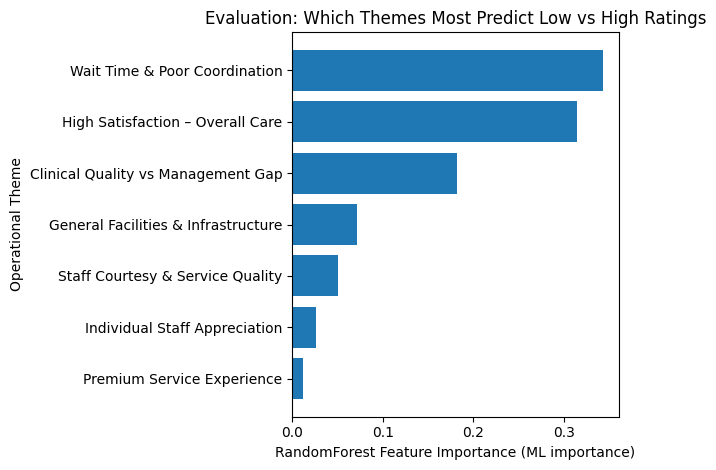

Saved: c:\Users\Admin\Downloads\clinsightai\outputs\eval_feature_importance.png


In [27]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd()
if (ROOT / "outputs").exists() is False and (ROOT.parent / "outputs").exists():
    ROOT = ROOT.parent

REPORT_PATH = ROOT / "outputs" / "clinsightai_report.json"
report = json.loads(REPORT_PATH.read_text(encoding="utf-8"))

theme_df = pd.DataFrame(report["theme_analysis"])

# Sort by ML importance (evaluation: shows what most drives rating class prediction)
plot_df = theme_df.sort_values("ml_importance", ascending=True)

plt.figure()
plt.barh(plot_df["theme"], plot_df["ml_importance"])
plt.xlabel("RandomForest Feature Importance (ML importance)")
plt.ylabel("Operational Theme")
plt.title("Evaluation: Which Themes Most Predict Low vs High Ratings")

out_path = ROOT / "outputs" / "eval_feature_importance.png"
plt.tight_layout()
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved:", out_path)